In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn import linear_model
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import tree
from sklearn import ensemble
from sklearn import metrics
from sklearn import cluster
from sklearn import feature_selection
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import VotingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.model_selection import RandomizedSearchCV

In [10]:
taxi_data = pd.read_csv("data/train.csv")
taxi_data['pickup_datetime']=pd.to_datetime(taxi_data['pickup_datetime'],format='%Y-%m-%d %H:%M:%S')
taxi_data['dropoff_datetime']=pd.to_datetime(taxi_data['dropoff_datetime'],format='%Y-%m-%d %H:%M:%S')

In [11]:
def add_datetime_features(df):
    df['pickup_date'] = df['pickup_datetime'].dt.date               # дата без времени
    df['pickup_hour'] = df['pickup_datetime'].dt.hour               # час дня (0–23)
    df['pickup_day_of_week'] = df['pickup_datetime'].dt.dayofweek   # день недели: 0=понедельник, 6=воскресенье
    return df
add_datetime_features(taxi_data)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_date,pickup_hour,pickup_day_of_week
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455,2016-03-14,17,0
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663,2016-06-12,0,6
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124,2016-01-19,11,1
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429,2016-04-06,19,2
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435,2016-03-26,13,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458639,id2376096,2,2016-04-08 13:31:04,2016-04-08 13:44:02,4,-73.982201,40.745522,-73.994911,40.740170,N,778,2016-04-08,13,4
1458640,id1049543,1,2016-01-10 07:35:15,2016-01-10 07:46:10,1,-74.000946,40.747379,-73.970184,40.796547,N,655,2016-01-10,7,6
1458641,id2304944,2,2016-04-22 06:57:41,2016-04-22 07:10:25,1,-73.959129,40.768799,-74.004433,40.707371,N,764,2016-04-22,6,4
1458642,id2714485,1,2016-01-05 15:56:26,2016-01-05 16:02:39,1,-73.982079,40.749062,-73.974632,40.757107,N,373,2016-01-05,15,1


In [12]:
holiday_data = pd.read_csv('data/holiday_data.csv', sep=';')

def add_holiday_features(taxi_df: pd.DataFrame, holiday_df: pd.DataFrame) -> pd.DataFrame:
    df = taxi_df.copy()
    holiday_dates = pd.to_datetime(holiday_df['date']).dt.date.unique()
    df['pickup_holiday'] = df['pickup_date'].isin(holiday_dates).astype(int)
    return df
taxi_data = add_holiday_features(taxi_data, holiday_data)

In [13]:
osrm_data = pd.read_csv('data/osrm_data_train.csv')

def add_osrm_features(taxi_df: pd.DataFrame, osrm_df: pd.DataFrame) -> pd.DataFrame:
    cols_to_merge = ['id', 'total_distance', 'total_travel_time', 'number_of_steps']
    df = pd.merge(
        taxi_df,
        osrm_df[cols_to_merge],
        on='id',
        how='left'
    )
    return df
taxi_data = add_osrm_features(taxi_data, osrm_data)

In [16]:
def get_haversine_distance(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # радиус земли в километрах
    EARTH_RADIUS = 6371 
    # считаем кратчайшее расстояние h по формуле Хаверсина
    lat_delta = lat2 - lat1
    lng_delta = lng2 - lng1
    d = np.sin(lat_delta * 0.5) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(lng_delta * 0.5) ** 2
    h = 2 * EARTH_RADIUS * np.arcsin(np.sqrt(d))
    return h

def get_angle_direction(lat1, lng1, lat2, lng2):
    # переводим углы в радианы
    lat1, lng1, lat2, lng2 = map(np.radians, (lat1, lng1, lat2, lng2))
    # считаем угол направления движения alpha по формуле угла пеленга
    lng_delta_rad = lng2 - lng1
    y = np.sin(lng_delta_rad) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(lng_delta_rad)
    alpha = np.degrees(np.arctan2(y, x))
    return alpha

def add_geographical_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    df['haversine_distance'] = get_haversine_distance(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    
    df['direction'] = get_angle_direction(
        df['pickup_latitude'], df['pickup_longitude'],
        df['dropoff_latitude'], df['dropoff_longitude']
    )
    
    return df

taxi_data = add_geographical_features(taxi_data)

In [17]:
# создаем обучающую выборку из географических координат всех точек
coords = np.hstack((taxi_data[['pickup_latitude', 'pickup_longitude']],
                    taxi_data[['dropoff_latitude', 'dropoff_longitude']]))
# обучаем алгоритм кластеризации
kmeans = cluster.KMeans(n_clusters=10, random_state=42)
kmeans.fit(coords)

# ваш код здесь
def add_cluster_features(df, kmeans):
    coords = np.hstack((df[['pickup_latitude', 'pickup_longitude']],
                    df[['dropoff_latitude', 'dropoff_longitude']]))
    df['geo_cluster']=kmeans.predict(coords)
    return df

taxi_data = add_cluster_features(taxi_data, kmeans)

c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [18]:
weather_data = pd.read_csv('data/weather_data.csv')
def add_weather_features(taxi_df: pd.DataFrame, weather_df: pd.DataFrame) -> pd.DataFrame:
    # Оставляем только нужные столбцы из weather_data
    weather_cols = ['time', 'temperature', 'visibility', 'wind speed', 'precip', 'events']
    weather = weather_df[weather_cols].copy()
    
    # Создаём столбцы date и hour для объединения
    weather['time'] = pd.to_datetime(weather['time'])
    weather['date'] = weather['time'].dt.date
    weather['hour'] = weather['time'].dt.hour
    
    # Удаляем исходный столбец time — он больше не нужен
    weather = weather.drop(columns=['time'])
    
    # Объединяем по дате и часу (left join — сохраняем все поездки)
    df = pd.merge(
        taxi_df,
        weather,
        left_on=['pickup_date', 'pickup_hour'],
        right_on=['date', 'hour'],
        how='left'
    )
    
    # Удаляем вспомогательные столбцы
    df = df.drop(columns=['date', 'hour'])
    
    return df
taxi_data = add_weather_features(taxi_data, weather_data)

In [19]:
def fill_null_weather_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    # Погодные числовые столбцы — заполняем медианой по дате
    weather_numeric_cols = ['temperature', 'visibility', 'wind speed', 'precip']
    for col in weather_numeric_cols:
        df[col] = df[col].fillna(
            df.groupby('pickup_date')[col].transform('median')
        )
    
    # Погодные явления — заполняем 'None'
    df['events'] = df['events'].fillna('None')
    
    # OSRM-столбцы — заполняем медианой по столбцу
    osrm_cols = ['total_distance', 'total_travel_time', 'number_of_steps']
    for col in osrm_cols:
        df[col] = df[col].fillna(df[col].median())
    
    return df
taxi_data = fill_null_weather_data(taxi_data)

In [20]:
avg_speed = taxi_data['total_distance'] / taxi_data['trip_duration'] * 3.6
threshold_seconds = 24 * 3600  # 86400 секунд
threshold_speed = 300
# Создаём маску:
mask_to_drop = (taxi_data['trip_duration'] > threshold_seconds) | (avg_speed > threshold_speed)
# Удаляем строки по индексам, где маска True
taxi_data = taxi_data[~mask_to_drop].copy()

In [21]:
taxi_data['is_rush_hour'] = (
    ((taxi_data['pickup_hour'] >= 7) & (taxi_data['pickup_hour'] <= 9)) |
    ((taxi_data['pickup_hour'] >= 16) & (taxi_data['pickup_hour'] <= 19))
).astype(int)

In [23]:
taxi_data['is_weekend'] = (taxi_data['pickup_day_of_week'] >= 5).astype(int)

In [24]:
taxi_data['hour_sin'] = np.sin(2 * np.pi * taxi_data['pickup_hour'] / 24)
taxi_data['hour_cos'] = np.cos(2 * np.pi * taxi_data['pickup_hour'] / 24)

taxi_data['dow_sin'] = np.sin(2 * np.pi * taxi_data['pickup_day_of_week'] / 7)
taxi_data['dow_cos'] = np.cos(2 * np.pi * taxi_data['pickup_day_of_week'] / 7)

In [25]:
# Финальные признаки для модели
feature_cols = [
    # Числовые (масштабируем)
    'haversine_distance',
    'direction',
    'total_distance',
    'total_travel_time',
    'number_of_steps',
    'temperature',
    'visibility',
    'wind speed',
    'precip',
    'passenger_count',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    
    # Бинарные (0/1) — оставляем как есть
    'is_weekend',
    'is_rush_hour',
    'pickup_holiday',
    
    # Категориальные (OneHot)
    'vendor_id',
    'store_and_fwd_flag',
    'events',
    'geo_cluster'
]

# Группы для ColumnTransformer
numeric_features = [
    'haversine_distance', 'direction', 'total_distance', 'total_travel_time',
    'number_of_steps', 'temperature', 'visibility', 'wind speed', 'precip',
    'passenger_count', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos'
]

binary_features = ['is_weekend', 'is_rush_hour', 'pickup_holiday']

categorical_onehot = ['vendor_id', 'store_and_fwd_flag', 'events', 'geo_cluster']

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Выделяем признаки и таргет
X = taxi_data[feature_cols]
y = np.log1p(taxi_data['trip_duration'])

# 2. Сначала отделяем holdout (наш внутренний "финальный" тест, 20%)
# На нём мы будем делать финальную оценку перед тем, как идти на настоящий внешний тест
X_temp, X_holdout, y_temp, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# 3. Теперь делим остаток на train и valid (для подбора гиперпараметров)
# valid будет 25% от остатка (то есть ~16% от всего)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True
)

print(f"Train: {X_train.shape[0]} строк")
print(f"Valid: {X_valid.shape[0]} строк")
print(f"Holdout: {X_holdout.shape[0]} строк")

Train: 874939 строк
Valid: 291647 строк
Holdout: 291647 строк


In [34]:
# Препроцессор (универсальный, подойдёт и для линейных, и для деревьев)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat_oh', OneHotEncoder(handle_unknown='ignore'), categorical_onehot)
    ]
)

# Пайплайн: предобработка + линейная регрессия
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LinearRegression())
])

# Обучаем на train
pipeline.fit(X_train, y_train)

# Прогноз на valid и holdout (в логарифмах)
y_pred_valid_log = pipeline.predict(X_valid)
y_pred_holdout_log = pipeline.predict(X_holdout)

# Функция для расчёта RMSLE

def calc_rmsle_from_log(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    # Не даём прогнозу уйти в минус — минимальная длительность поездки 0 секунд
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"RMSLE на валидации: {rmsle_valid:.4f}")
print(f"RMSLE на холд‑ауте: {rmsle_holdout:.4f}")

RMSLE на валидации: 0.5160
RMSLE на холд‑ауте: 0.5163


In [35]:
pipeline_ridge = Pipeline([
    ('preprocess', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # квадратичные взаимодействия
    ('model', Ridge(alpha=1.0))                                # регуляризация
])

pipeline_ridge.fit(X_train, y_train)
y_pred_valid_log = pipeline_ridge.predict(X_valid)
y_pred_holdout_log = pipeline_ridge.predict(X_holdout)

rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)
print(f"Ridge+Poly RMSLE valid: {rmsle_valid:.4f}, holdout: {rmsle_holdout:.4f}")

Ridge+Poly RMSLE valid: 0.4543, holdout: 0.4553


Оптимальная глубина: 11, RMSLE valid: 0.4265


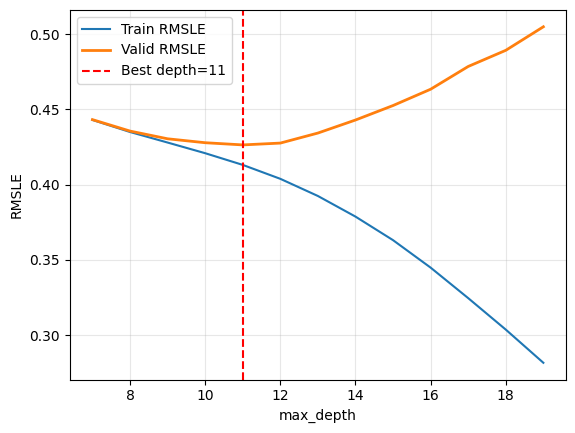

In [37]:
max_depths = range(7, 20)
valid_scores = []
train_scores = []

for d in max_depths:
    dt_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    dt_pipeline.fit(X_train, y_train)
    
    y_pred_train_log = dt_pipeline.predict(X_train)
    y_pred_valid_log = dt_pipeline.predict(X_valid)
    
    train_scores.append(calc_rmsle_from_log(y_train, y_pred_train_log))
    valid_scores.append(calc_rmsle_from_log(y_valid, y_pred_valid_log))

best_idx = np.argmin(valid_scores)
best_depth = max_depths[best_idx]
print(f"Оптимальная глубина: {best_depth}, RMSLE valid: {valid_scores[best_idx]:.4f}")

plt.plot(max_depths, train_scores, label='Train RMSLE')
plt.plot(max_depths, valid_scores, label='Valid RMSLE', linewidth=2)
plt.axvline(best_depth, color='red', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('RMSLE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=12,          # берём чуть больше, чем оптимальная для одного дерева
        random_state=42,
        n_jobs=-1              # используем все ядра CPU
    ))
])

rf_pipeline.fit(X_train, y_train)

y_pred_valid_log = rf_pipeline.predict(X_valid)
y_pred_holdout_log = rf_pipeline.predict(X_holdout)

rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"RandomForest RMSLE valid: {rmsle_valid:.4f}")
print(f"RandomForest RMSLE holdout: {rmsle_holdout:.4f}")

RandomForest RMSLE valid: 0.4112
RandomForest RMSLE holdout: 0.4110


In [41]:
gb_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(
        max_iter=500,          # количество деревьев
        learning_rate=0.05,    # скорость обучения
        max_depth=None,        # можно оставить None, он сам ограничит сложность
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

y_pred_valid_log = gb_pipeline.predict(X_valid)
y_pred_holdout_log = gb_pipeline.predict(X_holdout)

rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"HistGradientBoosting RMSLE valid: {rmsle_valid:.4f}")
print(f"HistGradientBoosting RMSLE holdout: {rmsle_holdout:.4f}")

HistGradientBoosting RMSLE valid: 0.4006
HistGradientBoosting RMSLE holdout: 0.3996


In [43]:
voting = VotingRegressor([
    ('ridge_poly', Pipeline([
        ('preprocess', preprocessor),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', Ridge(alpha=1.0))
    ])),
    ('rf', Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
    ])),
    ('gb', Pipeline([
        ('preprocess', preprocessor),
        ('model', HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=42))
    ]))
])

voting.fit(X_train, y_train)
y_pred_valid_log = voting.predict(X_valid)
y_pred_holdout_log = voting.predict(X_holdout)

rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)
print(f"Voting RMSLE valid: {rmsle_valid:.4f}, holdout: {rmsle_holdout:.4f}")

Voting RMSLE valid: 0.4091, holdout: 0.4088


In [45]:
# Базовые модели
estimators = [
    ('ridge_poly', Pipeline([
        ('preprocess', preprocessor),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', Ridge(alpha=1.0))
    ])),
    ('rf', Pipeline([
        ('preprocess', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
    ])),
    ('gb', Pipeline([
        ('preprocess', preprocessor),
        ('model', HistGradientBoostingRegressor(max_iter=500, learning_rate=0.05, random_state=42))
    ]))
]

# Мета‑модель: простая линейная регрессия (или Ridge)
meta_model = LinearRegression()

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=meta_model,
    cv=5,                # кросс‑валидация для получения прогнозов базовых моделей
    n_jobs=-1            # распараллеливание
)

stacking.fit(X_train, y_train)

y_pred_valid_log = stacking.predict(X_valid)
y_pred_holdout_log = stacking.predict(X_holdout)

rmsle_valid = calc_rmsle_from_log(y_valid, y_pred_valid_log)
rmsle_holdout = calc_rmsle_from_log(y_holdout, y_pred_holdout_log)

print(f"Stacking RMSLE valid: {rmsle_valid:.4f}")
print(f"Stacking RMSLE holdout: {rmsle_holdout:.4f}")

Stacking RMSLE valid: 0.4003
Stacking RMSLE holdout: 0.3993


In [53]:
# 1. Загрузка тестовых данных
test_data = pd.read_csv("data/Project5_test_data.csv")
osrm_data_test = pd.read_csv("data/Project5_osrm_data_test.csv")
test_id = test_data['id'].copy()

# 2. Datetime features (та же функция)
test_data['pickup_datetime'] = pd.to_datetime(
    test_data['pickup_datetime'], format='%Y-%m-%d %H:%M:%S'
)
test_data = add_datetime_features(test_data)

# 3. Holiday features
test_data = add_holiday_features(test_data, holiday_data)

# 4. OSRM merge
test_data = add_osrm_features(test_data, osrm_data_test)

# 5. Geographical features
test_data = add_geographical_features(test_data)

# 6. Cluster features — используем уже обученный kmeans!
test_data = add_cluster_features(test_data, kmeans)

# 7. Weather features
test_data = add_weather_features(test_data, weather_data)

# 8. Fill nulls
test_data = fill_null_weather_data(test_data)

# 9. Rush hour, weekend, sin/cos (то же, что и для train)
test_data['is_rush_hour'] = (
    ((test_data['pickup_hour'] >= 7) & (test_data['pickup_hour'] <= 9)) |
    ((test_data['pickup_hour'] >= 16) & (test_data['pickup_hour'] <= 19))
).astype(int)

test_data['is_weekend'] = (test_data['pickup_day_of_week'] >= 5).astype(int)

test_data['hour_sin'] = np.sin(2 * np.pi * test_data['pickup_hour'] / 24)
test_data['hour_cos'] = np.cos(2 * np.pi * test_data['pickup_hour'] / 24)

test_data['dow_sin'] = np.sin(2 * np.pi * test_data['pickup_day_of_week'] / 7)
test_data['dow_cos'] = np.cos(2 * np.pi * test_data['pickup_day_of_week'] / 7)

# 10. Отбираем те же колонки, что и в обучении
X_test = test_data[feature_cols].copy()

print("Тестовые данные готовы! Форма:", X_test.shape)

Тестовые данные готовы! Форма: (625134, 21)


In [54]:
# 11. Объединяем всё для финального обучения
X_full = pd.concat([X_train, X_valid, X_holdout], axis=0).reset_index(drop=True)
y_full = pd.concat([y_train, y_valid, y_holdout], axis=0).reset_index(drop=True)

# 12. Финальная модель
final_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', HistGradientBoostingRegressor(
        max_iter=500,
        learning_rate=0.05,
        random_state=42
    ))
])

print("Обучаю финальную модель на всех данных...")
final_pipeline.fit(X_full, y_full)
print("Готово!")

# 13. Прогноз
y_pred_log = final_pipeline.predict(X_test)
y_pred = np.expm1(y_pred_log)

# 14. Сохранение
submission = pd.DataFrame({
    'id': test_id,
    'trip_duration': y_pred
})
submission.to_csv('submission.csv', index=False)
print("submission.csv сохранён! Строк:", len(submission))

Обучаю финальную модель на всех данных...
Готово!
submission.csv сохранён! Строк: 625134
